# Интеллектуальный анализ данных – весна 2026
# Домашнее задание 6: классификация текстов

Правила:



*   Домашнее задание оценивается в 10 баллов.
*   Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.
*  Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.
*  Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.
*  Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.
* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

В этом домашнем задании вам предстоит построить классификатор текстов.

Будем предсказывать эмоциональную окраску твиттов о коронавирусе.



In [1]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('./tweets_coronavirus.csv', encoding='latin-1')
df.sample(4)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
16902,24373,69325,NaN,25-03-2020,@SpeakerPelosi is wearing earrings that are Ro...,Negative
24930,34317,79269,"Warri, Nigeria",06-04-2020,The same Trader who is busy hiking d prices of...,Positive
11497,17739,62691,"Boston, MA",21-03-2020,Will work for toilet paper. Serious inquiries ...,Positive
1694,5865,50817,"Hershey, PA",17-03-2020,While the PA State Police Museum is closed to ...,Extremely Positive


Для каждого твитта указано:


*   UserName - имя пользователя, заменено на целое число для анонимности
*   ScreenName - отображающееся имя пользователя, заменено на целое число для анонимности
*   Location - местоположение
*   TweetAt - дата создания твитта
*   OriginalTweet - текст твитта
*   Sentiment - эмоциональная окраска твитта (целевая переменная)



## Задание 1 Подготовка (0.5 балла)

Целевая переменная находится в колонке `Sentiment`.  Преобразуйте ее таким образом, чтобы она стала бинарной: 1 - если у твитта положительная или очень положительная эмоциональная окраска и 0 - если отрицательная или очень отрицательная.

In [3]:
df.Sentiment.value_counts()

Sentiment
Positive              11422
Negative               9917
Extremely Positive     6624
Extremely Negative     5481
Name: count, dtype: int64

In [4]:
df["Sentiment"] = df.Sentiment.isin(["Positive", "Extremely Positive"]).astype(int)
df.head(5)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,1
1,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,1
2,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,1
3,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",0
4,3804,48756,"ÃÂT: 36.319708,-82.363649",16-03-2020,As news of the regionÃÂs first confirmed COV...,1


Сбалансированы ли классы?

In [5]:
pos_cnt = (df.Sentiment == 1).sum()
neg_cnt = (df.Sentiment == 0).sum()
ir = np.max((pos_cnt, neg_cnt)) / np.min((pos_cnt, neg_cnt))

print(f"Imbalance ratio: {ir}")

Imbalance ratio: 1.171970385764385


**Ответ:** Коэффициент дисбаланса примерно равен 1, поэтому мы можем считать, что выборка сбалансирована

Выведете на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их строкой 'Unknown'.

In [6]:
df.isna().sum()

UserName            0
ScreenName          0
Location         7049
TweetAt             0
OriginalTweet       0
Sentiment           0
dtype: int64

Пропуски присутствуют в колонке `Location`

In [7]:
df.Location = df.Location.fillna("Unknown")

Разделите данные на обучающие и тестовые в соотношении 7 : 3 и укажите `random_state=0`

In [8]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
	df,
	test_size=0.3,
	random_state=0,
)

## Задание 2 Токенизация (3 балла)

Постройте словарь на основе обучающей выборки и посчитайте количество встреч каждого токена с использованием самой простой токенизации - деления текстов по пробельным символам и приведения токенов в нижний регистр.

In [9]:
tokens = (
	train
		.OriginalTweet
		.str.replace(r"\s+", " ", regex=True)
		.str.lower()
		.str.split(" ")
		.explode()
)

vocab = tokens.value_counts()
vocab

OriginalTweet
the                        26815
to                         23373
and                        14684
of                         13012
a                          11737
                           ...  
flew                           1
nothing...                     1
@torontopearson                1
@680news                       1
https://t.co/7j2y3rsld9        1
Name: count, Length: 79756, dtype: int64

Какой размер словаря получился?

In [10]:
print(f"Vocabulary size is: {vocab.size}")

Vocabulary size is: 79756


Выведите 10 самых популярных токенов с количеством встреч каждого из них. Объясните, почему именно эти токены в топе.

In [11]:
vocab.sort_values(ascending=False).head(10)

OriginalTweet
the             26815
to              23373
and             14684
of              13012
a               11737
in              11198
for              8566
#coronavirus     8223
is               7383
are              7050
Name: count, dtype: int64

**Ответ:** В топе в основном служебные слова английского языка, потому что они встречаются почти в каждом предложении. Но также есть хэштег #coronavirus, который встречается часто, т.к. такова тематика датасета.

Удалите стоп-слова из словаря и выведите новый топ-10 токенов (и количество встреч) по популярности.  Что можно сказать  о нем?

In [12]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

filtered_vocab = tokens[~tokens.isin(stop_words)].value_counts()
filtered_vocab.sort_values(ascending=False).head(10)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/variaxxx/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


OriginalTweet
#coronavirus    8223
prices          3891
food            3820
grocery         3469
supermarket     3288
people          3175
covid-19        3173
store           3155
#covid19        2471
&amp;           2314
Name: count, dtype: int64

**Ответ:** В новом топе остались слова, отражающие содержательную тематику текстов. Они несут основной смысл и связаны с волнующими людей темами (цены, еда, магазины).  

Также выведите 20 самых непопулярных слов (если самых непопулярных слов больше, выведите любые 20 из них) Почему эти токены непопулярны, требуется ли как-то дополнительно работать с ними?

In [13]:
filtered_vocab.sort_values().head(20)

OriginalTweet
damanding                  1
#bewell                    1
understandable             1
*totally*                  1
mb                         1
4/4/2020.                  1
3/29/2020                  1
@marketbasket              1
@donatopmancini            1
https://t.co/qktrfpzpip    1
universityãâs            1
https://t.co/xs3ihhvsvr    1
'doomed'!                  1
michigan??                 1
grocery/supermarket        1
luxury,                    1
@vic_rollison              1
@tranzalored               1
dignity."                  1
#donothoard                1
Name: count, dtype: int64

**Ответ:** В текстах очень много токенов, которые встретились ровно по одному разу. Среди них ссылки, хэштеги, упоминания, даты и слова, склеившиеся с различными вспомогательными символами. Такие токены редко встречаются из-за своей специфичности. Эти токены следовало бы удалить, потому что они не добавляют качества, а только увеличивают словарь.

Теперь воспользуемся токенайзером получше - TweetTokenizer из библиотеки nltk. Примените его и посмотрите на топ-10 популярных слов. Чем он отличается от топа, который получался раньше? Почему?

In [14]:
from nltk.tokenize import TweetTokenizer

tokenizer = TweetTokenizer()

tokens = train.OriginalTweet.apply(tokenizer.tokenize).explode()
vocab = tokens.value_counts()

In [15]:
vocab.sort_values(ascending=False).head(10)

OriginalTweet
the    24337
.      24118
to     22933
,      17571
and    14354
of     12904
a      11045
in     10573
?       9524
for     8228
Name: count, dtype: int64

**Ответ:** Теперь в топе помимо служебных слов английского языка появились знаки препинания. Это означает, что данный токенайзер отделяет токены не по пробельным символам, а более сложным методом.

Удалите из словаря стоп-слова и пунктуацию, посмотрите на новый топ-10 слов с количеством встреч, есть ли теперь в нем что-то не похожее на слова?

In [16]:
from string import punctuation

vocab = vocab[~vocab.index.isin(list(punctuation)) & ~vocab.index.isin(stop_words)]

In [17]:
vocab.sort_values(ascending=False).head(10)

OriginalTweet
Â               7415
               7311
19              7167
#coronavirus    7143
I               5235
               4372
prices          4281
COVID           4218
food            3795
store           3691
Name: count, dtype: int64

**Ответ:** В топе символ Â и еще пара неотображаемых символов, которые не помогут нам в классификации.

Скорее всего в некоторых топах были неотображаемые символы или отдельные буквы не латинского алфавита. Уберем их: удалите из словаря токены из одного символа, позиция которого в таблице Unicode 128 и более (`ord(x) >= 128`)

Выведите топ-10 самых популярных и топ-20 непопулярных слов. Чем полученные топы отличаются от итоговых топов, полученных при использовании токенизации по пробелам? Что теперь лучше, а что хуже?

In [18]:
vocab = vocab[~vocab.index.map(lambda x: len(x) == 1 and ord(x) >= 128)]

In [19]:
vocab.sort_values(ascending=False).head(10)

OriginalTweet
19              7167
#coronavirus    7143
I               5235
prices          4281
COVID           4218
food            3795
store           3691
supermarket     3373
grocery         3083
people          3047
Name: count, dtype: int64

In [20]:
vocab.sort_values().head(20)

OriginalTweet
Cent                       1
https://t.co/VElBZOzejf    1
https://t.co/qreFmWVPzN    1
Unfailingly                1
MEP                        1
Herbert                    1
Dorfmann                   1
https://t.co/2SmLN097Kn    1
#pulses                    1
https://t.co/vUR18Qt9yG    1
@Other_Caroline            1
https://t.co/qjzWPrEBso    1
https://t.co/kW2LQYI0Er    1
@nickreeves9876            1
Kitsap                     1
@calmecam                  1
#performance               1
Eyren                      1
Industrie                  1
https://t.co/QJdnMALd4m    1
Name: count, dtype: int64

**Ответ:** В новом топ 10 не встречается пунктуации, а так остались почти все те же слова что и в старом топе. Также количества встреч отличаются от старого топа, т.к. старый токенайзер приводил слова к нижнему регистру. В топ 20 непопулярных слов все также попадают имена, упоминания и ссылки, но пропали слова, склеившиеся с пунктуацией. В целом новый токенайзер сильно лучше, но следовало бы убрать чувствительность к регистру.

Выведите топ-10 популярных хештегов (токены, первые символы которых - #) с количеством встреч. Что можно сказать о них?

In [21]:
hashtag_vocab = vocab[vocab.index.str.startswith("#")]
hashtag_vocab.sort_values(ascending=False).head(10)

OriginalTweet
#coronavirus     7143
#COVID19         1844
#Covid_19        1463
#Coronavirus     1281
#COVID2019        927
#toiletpaper      657
#covid19          568
#COVID            542
#CoronaCrisis     426
#CoronaVirus      351
Name: count, dtype: int64

**Ответ:** Почти все хэштеги это упоминания коронавируса в разных формах и регистрах. Часто упоминается toiletpaper, без которой нельзя представить жизнь во время пандемии. 

То же самое проделайте для ссылок на сайт https://t.co Сравнима ли популярность ссылок с популярностью хештегов? Будет ли информация о ссылке на конкретную страницу полезна?

In [22]:
link_vocab = vocab[vocab.index.str.startswith("https://t.co")]
link_vocab.sort_values(ascending=False).head(10)

OriginalTweet
https://t.co/oXA7SWtoNd    5
https://t.co/gP3EusapL8    4
https://t.co/CATKegAyOY    3
https://t.co/OI39zSAnQ8    3
https://t.co/WuiEEfSNOj    3
https://t.co/AZIqCdgrNn    3
https://t.co/G63RP042HO    3
https://t.co/bYlqXrjmNT    3
https://t.co/e2ZNXajPre    3
https://t.co/3GBBDpdjat    3
Name: count, dtype: int64

**Ответ:** Популярности ссылок и хэштегов абсолютно не сравнимы. Ссылки очень редко встречаются повторно, поэтому  информация о ссылке на конкретную страницу не пригодится для решения нашей задачи.

Используем опыт предыдущих экспериментов и напишем собственный токенайзер, улучшив TweetTokenizer. Функция tokenize должна:



*   Привести текст в нижний регистр
*   Применить TweetTokenizer для  выделения токенов
*   Удалить стоп-слова, пунктуацию, токены из одного символа с позицией в таблице Unicode 128 и более,  ссылки на t.co



In [23]:
stop_words = set(stopwords.words("english"))

tt = TweetTokenizer()

def custom_tokenizer(text):
	tokens = np.array(tt.tokenize(text.lower()))
	
	mask = np.array([
		token not in stop_words
		and token not in punctuation
		and not (len(token) == 1 and ord(token) >= 128)
		and not token.startswith("https://t.co")
		for token in tokens
	])

	return tokens[mask]

In [24]:
custom_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext')

array(['sample', 'text', '@sample_text', '#sampletext'], dtype='<U19')

## Задание 3 Векторизация текстов (2 балла)

Обучите CountVectorizer с использованием custom_tokenizer в качестве токенайзера. Как размер полученного словаря соотносится с размером изначального словаря из начала задания 2?

In [25]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(tokenizer=custom_tokenizer).fit(train.OriginalTweet)

print(len(cv.vocabulary_))

45290


**Ответ:** Полученный словарь почти в 2 раза меньше словаря из начала задания 2 благодаря написанным ранее фильтрам (стоп-слова и т.д.). 

Посмотрим на какой-нибудь конкретный твитт:

In [26]:
ind = 9023
train.iloc[ind]['OriginalTweet'], train.iloc[ind]['Sentiment']

('Nice one @SkyNews lets not panic but show ppl in france queueing for food!!! #CoronavirusOutbreak #COVID2019 brainless!! Ffs',
 np.int64(0))

Автор твитта не доволен ситуацией с едой во Франции и текст имеет резко негативную окраску.

Примените обученный CountVectorizer для векторизации данного текста, и попытайтесь определить самый важный токен и самый неважный токен (токен, компонента которого в векторе максимальна/минимальна, без учета 0). Хорошо ли они определились, почему?

In [27]:
X = cv.transform([train.iloc[ind].OriginalTweet]).toarray()[0]
features = cv.get_feature_names_out()

nonzero_idx = X.nonzero()[0]
nonzero_values = X[nonzero_idx]
nonzero_tokens = features[nonzero_idx]

max_idx = nonzero_values.argmax()
min_idx = nonzero_values.argmin()

print(f"Most important token: {nonzero_tokens[max_idx]}")
print(f"Less important token: {nonzero_tokens[min_idx]}")

Most important token: #coronavirusoutbreak
Less important token: #coronavirusoutbreak


In [28]:
nonzero_values

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

**Ответ:** Самый важный и самый неважный оказались одним и тем же токеном, т.к. векторайзер выдал массив, содержащий кроме нулей лишь 14 единиц. Так вышло, т.к. каждое из слов в твите встречалось по одному разу.

Теперь примените TfidfVectorizer и  определите самый важный/неважный токены. Хорошо ли определились, почему?

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(tokenizer=custom_tokenizer).fit(train.OriginalTweet)

In [30]:
X = tfidf.transform([train.iloc[ind].OriginalTweet]).toarray()[0]
features = tfidf.get_feature_names_out()

nonzero_idx = X.nonzero()[0]
nonzero_values = X[nonzero_idx]
nonzero_tokens = features[nonzero_idx]

max_idx = nonzero_values.argmax()
min_idx = nonzero_values.argmin()

print(f"Most important token: {nonzero_tokens[max_idx]}")
print(f"Less important token: {nonzero_tokens[min_idx]}")

Most important token: brainless
Less important token: food


**Ответ:** Самым важным оказался токен `brainless`, что вполне правдиво, т.к. он имеет негативную окраску. Наименее важным стал токен `food`, что тоже правдиво, т.к. это слово встречается часто и может использоваться в твитах с разной эмоциональной окраской. TfidfVectorizer оказался лучше CountVectorizer, т.к. первый учитывает количество встреч токена во всех документах из обучающей выборки. 

Найдите какой-нибудь положительно окрашенный твитт, где TfidfVectorizer хорошо (полезно для определения окраски) выделяет важный токен, поясните пример.

*Подсказка:* явно положительные твитты можно искать при помощи положительных слов (good, great, amazing и т. д.)

In [31]:
ind = 2
pos_tweet = train[train['OriginalTweet'].apply(lambda x: 'amazing' in x) & (train['Sentiment'] == 1)].iloc[ind]
pos_tweet.OriginalTweet

'Back at the "Frontline"\r\r\nA massive shout out to all the NHS staff pharmacy staff shop and supermarket workers road sweepers etc who are braving the Frontline and are doing an amazing job day in day out\r\r\n#coronavirus #covid19UK https://t.co/I0pVlh5bvx'

In [32]:
X = tfidf.transform([pos_tweet.OriginalTweet]).toarray()[0]
features = tfidf.get_feature_names_out()

nonzero_idx = X.nonzero()[0]

token_scores = pd.Series(
	X[nonzero_idx],
	index=features[nonzero_idx]
).sort_values(ascending=False)

token_scores

frontline       0.419890
sweepers        0.322969
braving         0.313643
staff           0.302083
day             0.298019
shout           0.228671
road            0.223256
massive         0.210613
amazing         0.207401
pharmacy        0.195292
#covid19uk      0.194667
nhs             0.189346
job             0.177210
etc             0.174662
back            0.158913
shop            0.154981
workers         0.125593
supermarket     0.091983
#coronavirus    0.064283
dtype: float64

**Ответ:** В приведенном твите выражается благодарность работникам продуктовых магазинов и прочим людям. Векторайзер полезно выделил важные токены `frontline` и `braving`, потому что они явно говорят о положительной окраске твита.

## Задание 4 Обучение первых моделей (1 балл)

Примените оба векторайзера для получения матриц с признаками текстов.  Выделите целевую переменную.

In [33]:
X_cv_train = cv.transform(train.OriginalTweet)
X_cv_test = cv.transform(test.OriginalTweet)

X_tfidf_train = tfidf.transform(train.OriginalTweet)
X_tfidf_test = tfidf.transform(test.OriginalTweet)

y_train = train.Sentiment
y_test = test.Sentiment

Обучите логистическую регрессию на векторах из обоих векторайзеров. Посчитайте долю правильных ответов на обучающих и тестовых данных. Какой векторайзер показал лучший результат? Что можно сказать о моделях?

Используйте `sparse` матрицы (после векторизации), не превращайте их в `numpy.ndarray` или `pd.DataFrame` - может не хватить памяти.

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_cv = LogisticRegression().fit(X_cv_train, y_train)
model_tfidf = LogisticRegression().fit(X_tfidf_train, y_train)

print("LogisticRegression with CountVectorizer")
print(f"\tTrain accuracy: {accuracy_score(y_train, model_cv.predict(X_cv_train))}")
print(f"\tTest accuracy: {accuracy_score(y_test, model_cv.predict(X_cv_test))}")

print("LogisticRegression with TfidfVectorizer")
print(f"\tTrain accuracy: {accuracy_score(y_train, model_tfidf.predict(X_tfidf_train))}")
print(f"\tTest accuracy: {accuracy_score(y_test, model_tfidf.predict(X_tfidf_test))}")

LogisticRegression with CountVectorizer
	Train accuracy: 0.9846646732165741
	Test accuracy: 0.8670520231213873
LogisticRegression with TfidfVectorizer
	Train accuracy: 0.9224263135412217
	Test accuracy: 0.85280047837353


**Ответ:** Логистическая регрессия с count векторайзером показала лучший результат. У модели с CountVectorizer accuracy на train сильно выше, чем на test, а значит модель переобучилась. У модели с TfidfVectorizer переобучение меньше.

## Задание 5 Стемминг (0.5 балла)

Для уменьшения словаря можно использовать стемминг.

Модифицируйте написанный токенайзер, добавив в него стемминг с использованием SnowballStemmer. Обучите Count- и Tfidf- векторайзеры. Как изменился размер словаря?

In [35]:
from nltk.stem.snowball import SnowballStemmer

stemmer = np.vectorize(SnowballStemmer("english").stem)

def custom_stem_tokenizer(text):
  return stemmer(custom_tokenizer(text))

In [36]:
custom_stem_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext adding more words to check stemming')

array(['sampl', 'text', '@sample_text', '#sampletext', 'ad', 'word',
       'check', 'stem'], dtype='<U12')

In [37]:
cv = CountVectorizer(tokenizer=custom_stem_tokenizer).fit(train.OriginalTweet)
tfidf = TfidfVectorizer(tokenizer=custom_stem_tokenizer).fit(train.OriginalTweet)

print(f"CountVectorizer vocabulary: {len(cv.vocabulary_)}")
print(f"TfidfVectorizer vocabulary: {len(tfidf.vocabulary_)}")

CountVectorizer vocabulary: 36634
TfidfVectorizer vocabulary: 36634


**Ответ** Размер словаря уменьшился с 45290 токенов до 36634 благодаря приведению слов к общему стему.

Обучите логистическую регрессию с использованием обоих векторайзеров. Изменилось ли качество? Есть ли смысл применять стемминг?

In [38]:
X_cv_train = cv.transform(train.OriginalTweet)
X_cv_test = cv.transform(test.OriginalTweet)

X_tfidf_train = tfidf.transform(train.OriginalTweet)
X_tfidf_test = tfidf.transform(test.OriginalTweet)

y_train = train.Sentiment
y_test = test.Sentiment

In [39]:
model_cv = LogisticRegression().fit(X_cv_train, y_train)
model_tfidf = LogisticRegression().fit(X_tfidf_train, y_train)

print("LogisticRegression with CountVectorizer with stemming")
print(f"\tTrain accuracy: {accuracy_score(y_train, model_cv.predict(X_cv_train))}")
print(f"\tTest accuracy: {accuracy_score(y_test, model_cv.predict(X_cv_test))}")

print("LogisticRegression with TfidfVectorizer with stemming")
print(f"\tTrain accuracy: {accuracy_score(y_train, model_tfidf.predict(X_tfidf_train))}")
print(f"\tTest accuracy: {accuracy_score(y_test, model_tfidf.predict(X_tfidf_test))}")

LogisticRegression with CountVectorizer with stemming
	Train accuracy: 0.9720205040580948
	Test accuracy: 0.8674506677297189
LogisticRegression with TfidfVectorizer with stemming
	Train accuracy: 0.9165741136266553
	Test accuracy: 0.8559896352401833


**Ответ:** Стемминг для обоих векторайзеров повысил accuracy на test, но понизил на train. Прирост почти незаметен, поэтому трудно сказать о смысле использования стемминга. 

## Задание  6 Работа с частотами (1.5 балла)

Еще один способ уменьшить количество признаков - это использовать параметры min_df и max_df при построении векторайзера  эти параметры помогают ограничить требуемую частоту встречаемости токена в документах.

По умолчанию берутся все токены, которые встретились хотя бы один раз.



Подберите max_df такой, что размер словаря будет 36651 (на 1 меньше, чем было). Почему параметр получился такой большой/маленький?

In [40]:
target = len(cv.vocabulary_) - 1

best_max_df = 1.0
best_size = 0
mi, ma = 0.0, 1.0

for _ in range(10):
    mid = (ma + mi) / 2

    try:
        cv_df = CountVectorizer(
            tokenizer=custom_stem_tokenizer,
            max_df=mid
        ).fit(train.OriginalTweet)
    except ValueError:
        mi = mid
        continue
    
    size = len(cv_df.vocabulary_)
    print(f"max_df={mid}; size={size};")
    
    if size > target:
        ma = mid
    elif size < target:
        mi = mid
    else:
        best_max_df = mid
        best_size = size
        break

best_max_df, best_size

max_df=0.5; size=36634;
max_df=0.25; size=36631;
max_df=0.375; size=36634;
max_df=0.3125; size=36633;


(0.3125, 36633)

**Ответ:** Подходящим значением `max_df` стало 0.3125. Это означает, что только один токен встречается более чем в 31.25% твитов.

Подберите min_df (используйте дефолтное значение max_df) в CountVectorizer таким образом, чтобы размер словаря был 3700 токенов (при использовании токенайзера со стеммингом), а качество осталось таким же, как и было. Что можно сказать о результатах?

In [41]:
target = 3700
eps = 20

best_min_df = 1.0
best_size = 0
mi, ma = 0.0, 1.0

for _ in range(30):
    mid = (ma + mi) / 2

    try:
        cv_df = CountVectorizer(
            tokenizer=custom_stem_tokenizer,
            min_df=mid
        ).fit(train.OriginalTweet)
    except ValueError:
        ma = mid
        continue
    
    size = len(cv_df.vocabulary_)
    print(f"min_df={mid}; size={size};")
    
    if size > target + eps:
        mi = mid
    elif size < target - eps:
        ma = mid
    else:
        best_min_df = mid
        best_size = size
        break    

best_min_df, best_size

min_df=0.25; size=3;
min_df=0.125; size=9;
min_df=0.0625; size=28;
min_df=0.03125; size=69;
min_df=0.015625; size=184;
min_df=0.0078125; size=435;
min_df=0.00390625; size=822;
min_df=0.001953125; size=1440;
min_df=0.0009765625; size=2275;
min_df=0.00048828125; size=3476;
min_df=0.000244140625; size=5527;
min_df=0.0003662109375; size=4186;
min_df=0.00042724609375; size=3687;


(0.00042724609375, 3687)

In [42]:
cv_min_df = CountVectorizer(
    tokenizer=custom_stem_tokenizer,
    min_df=best_min_df,
).fit(train.OriginalTweet)

In [43]:
X_train = cv_min_df.transform(train.OriginalTweet)
X_test = cv_min_df.transform(test.OriginalTweet)

In [44]:
model_cv_min_df = LogisticRegression().fit(X_train, y_train)

print("LogisticRegression with CountVectorizer and min_df")
print(f"\tTrain accuracy: {accuracy_score(y_train, model_cv_min_df.predict(X_train))}")
print(f"\tTest accuracy: {accuracy_score(y_test, model_cv_min_df.predict(X_test))}")

LogisticRegression with CountVectorizer and min_df
	Train accuracy: 0.9290046988466467
	Test accuracy: 0.8680486346422165


**Ответ:** accuracy на train немного снизилась, а на test повысилась. Это значит, что удаление низкочастотных токенов уменьшило переобучение: модель стала меньше запоминать специфичные слова и лучше обобщать.

В предыдущих заданиях признаки не скалировались. Отскалируйте данные (при словаре размера 3.7 тысяч, векторизованные CountVectorizer), обучите логистическую регрессию, посмотрите качество и выведите `barplot`, содержащий по 10 токенов, с наибольшим по модулю положительными/отрицательными весами. Что можно сказать об этих токенах?

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False).fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

model = LogisticRegression().fit(scaled_X_train, y_train)

print("LogisticRegression with CountVectorizer, min_df and StandardScaler")
print(f"\tTrain accuracy: {accuracy_score(y_train, model.predict(scaled_X_train))}")
print(f"\tTest accuracy: {accuracy_score(y_test, model.predict(scaled_X_test))}")

LogisticRegression with CountVectorizer, min_df and StandardScaler
	Train accuracy: 0.9414780008543358
	Test accuracy: 0.8447279250548136


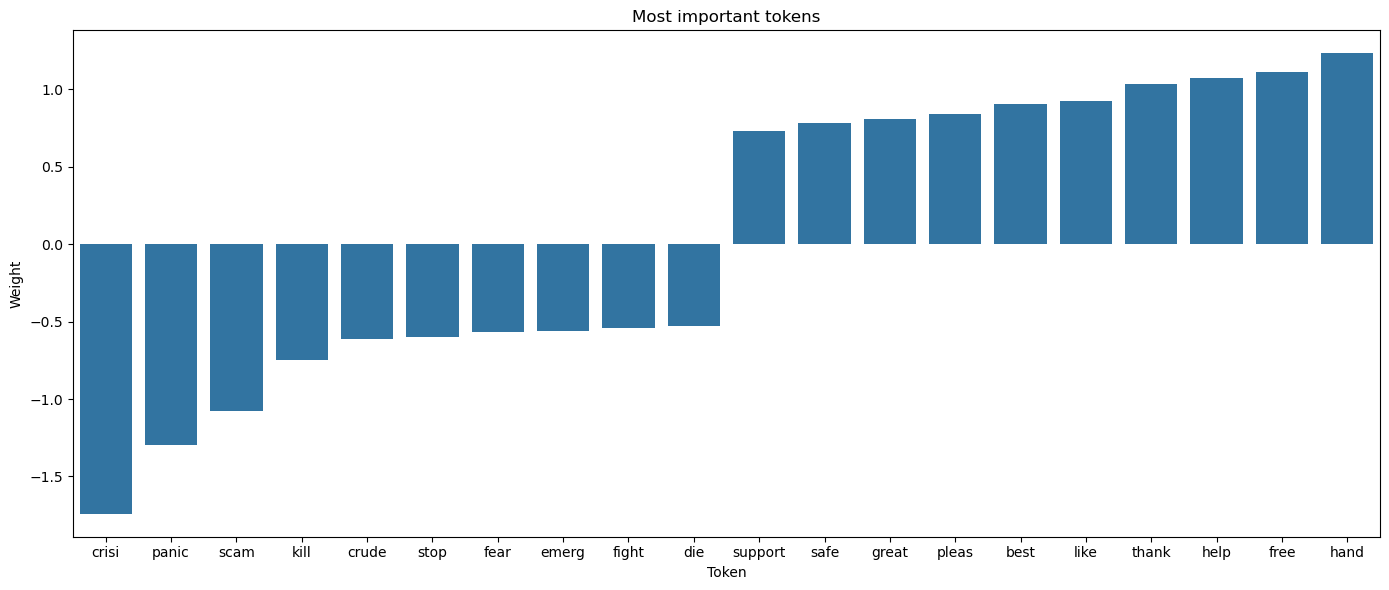

In [46]:
coef_df = pd.Series(
    model.coef_[0],
    index=cv_min_df.get_feature_names_out(),
)

imp_tokens = pd.concat([
    coef_df.sort_values(ascending=False).head(10),
    coef_df.sort_values().head(10)
]).sort_values()

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    x=imp_tokens.index,
    y=imp_tokens.values,
    ax=ax,
)

ax.set_title("Most important tokens")
ax.set_xlabel("Token")
ax.set_ylabel("Weight")
plt.tight_layout()

**Ответ:** Для логистической регрессии accuracy на train повысилась, а на test уменьшилась, что говорит о переобучении. Среди самых важных токенов на графике оказались токены, которые явно говорят о окраске твита, например panic (негативный) или thank (позитивный).

## Задание 7 Другие признаки (1.5 балла)

Мы были сконцентрированы на работе с текстами твиттов и не использовали другие признаки - имена пользователя, дату и местоположение

Изучите признаки UserName и ScreenName. полезны ли они? Если полезны, то закодируйте их, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [47]:
df.UserName.value_counts().sort_values()

UserName
3800     1
31047    1
31046    1
31045    1
31044    1
        ..
17318    1
17317    1
17316    1
17313    1
44955    1
Name: count, Length: 33444, dtype: int64

In [48]:
df.UserName.size == df.UserName.unique().size

True

In [49]:
df.ScreenName.size == df.ScreenName.unique().size

True

**Ответ:** Признаки `UserName` и `ScreenName` уникальны для каждой записи в датасете, а значит они не могут быть полезными для решения нашей задачи.

Изучите признак TweetAt в обучающей выборке: преобразуйте его к типу datetime и нарисуйте его гистограмму с разделением по цвету на основе целевой переменной. Полезен ли он? Если полезен, то закодируйте его, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [50]:
train.TweetAt = pd.to_datetime(
    train.TweetAt,
    format="%d-%m-%Y"
)

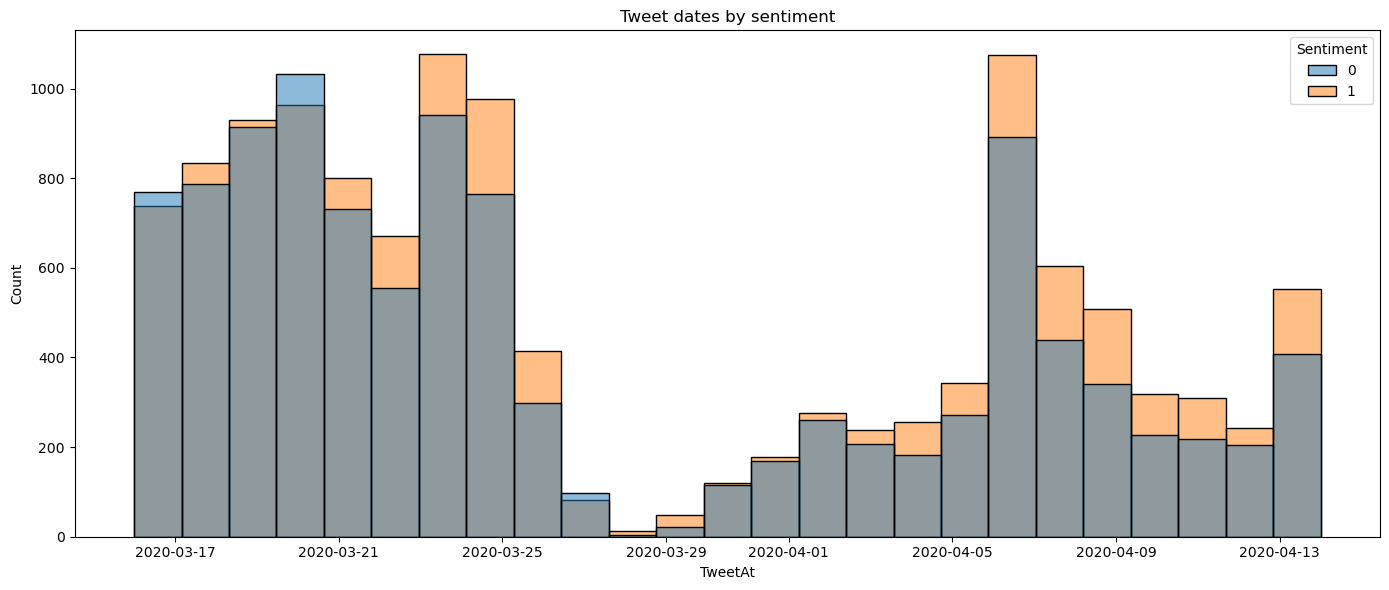

In [51]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.histplot(
    data=train,
    x="TweetAt",
    hue="Sentiment",
    ax=ax,
)

ax.set_title("Tweet dates by sentiment")
plt.tight_layout()

Есть пики для положительной окраски, поэтому можно попробовать обучить модель с использованием этого признака.

In [52]:
test.TweetAt = pd.to_datetime(
    test.TweetAt,
    format="%d-%m-%Y"
)

In [53]:
from sklearn.preprocessing import OneHotEncoder

tweet_at_ohe = OneHotEncoder(
    handle_unknown="ignore",
).fit(train[["TweetAt"]])

train_tweet_at = tweet_at_ohe.transform(train[["TweetAt"]])
test_tweet_at = tweet_at_ohe.transform(test[["TweetAt"]])

In [54]:
from scipy.sparse import hstack

tweet_X_train = hstack([scaled_X_train, train_tweet_at])
tweet_X_test = hstack([scaled_X_test, test_tweet_at])

In [55]:
model = LogisticRegression().fit(tweet_X_train, y_train)

print("LogisticRegression with CountVectorizer, min_df, StandardScaler and TweetAt")
print(f"\tTrain accuracy: {accuracy_score(y_train, model.predict(tweet_X_train))}")
print(f"\tTest accuracy: {accuracy_score(y_test, model.predict(tweet_X_test))}")

LogisticRegression with CountVectorizer, min_df, StandardScaler and TweetAt
	Train accuracy: 0.9425459205467749
	Test accuracy: 0.8432330077735699


**Ответ:** train accuracy повысился, а test понизился, значит смысла от этого признака не было. 

Поработайте с признаком Location в обучающей выборке. Сколько уникальных значений?

In [56]:
print(f"Unique Location values count: {train.Location.unique().size}")

Unique Location values count: 7949


Постройте гистограмму топ-10 по популярности местоположений (исключая Unknown)

In [57]:
top_locs = train.Location[train.Location != "Unknown"].value_counts().sort_values(ascending=False).head(10).index
top_locs

Index(['London', 'United States', 'London, England', 'New York, NY',
       'Washington, DC', 'United Kingdom', 'Los Angeles, CA', 'India', 'UK',
       'Australia'],
      dtype='str', name='Location')

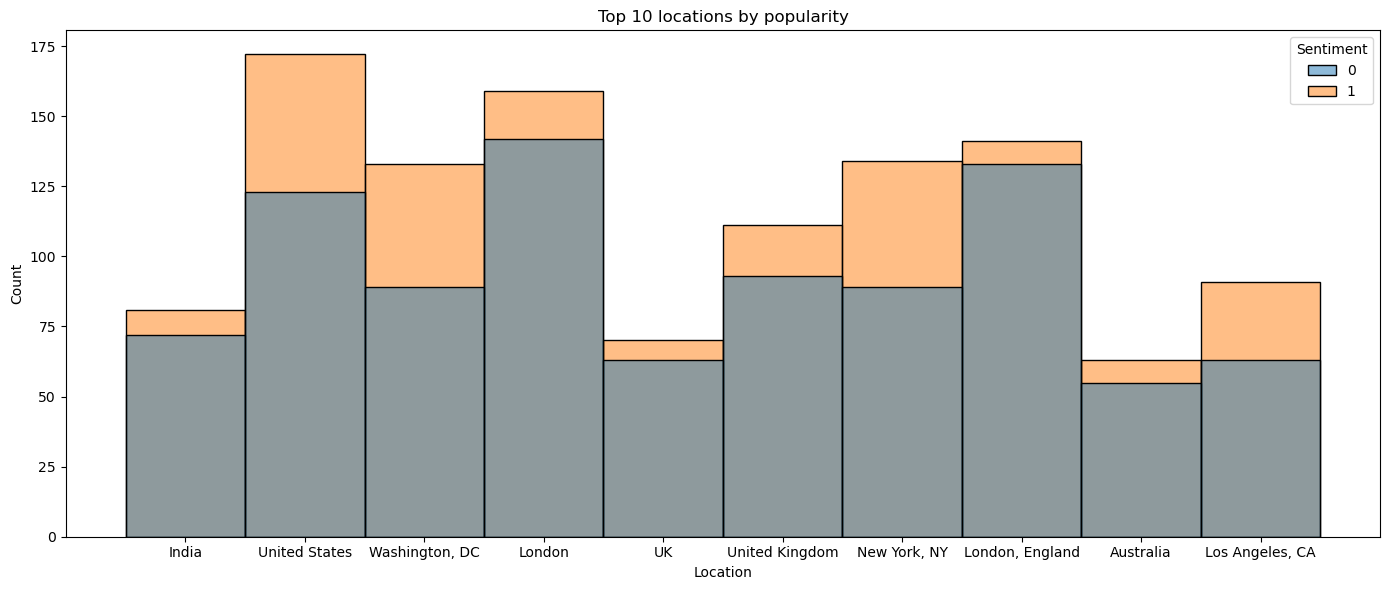

In [58]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.histplot(
    data=train[train.Location.isin(top_locs)],
    x="Location",
    hue="Sentiment",
)

ax.set_title("Top 10 locations by popularity")
plt.tight_layout()

Видно, что многие местоположения включают в себя более точное название места, чем другие (Например, у некоторых стоит London, UK; а у некоторых просто UK или United Kingdom).

Создайте новый признак WiderLocation, который содержит самое широкое местоположение (например, из London, UK должно получиться UK). Сколько уникальных категорий теперь? Постройте аналогичную гистограмму.

In [59]:
train["WiderLocation"] = train.Location.str.split(",").str[-1].str.strip()
train.WiderLocation.value_counts()

WiderLocation
Unknown                       4944
USA                            962
England                        873
CA                             607
India                          547
                              ... 
FL / Noord-Brabant               1
North Texas                      1
Whitehouse Bar & Pool Room       1
hyderabad                        1
NIGERIA                          1
Name: count, Length: 4631, dtype: int64

In [60]:
train.WiderLocation.unique().size

4631

Теперь 4631 уникальная категория

In [61]:
top_wider_locs = train.WiderLocation[train.WiderLocation != "Unknown"].value_counts().sort_values(ascending=False).head(10).index
top_wider_locs

Index(['USA', 'England', 'CA', 'India', 'NY', 'UK', 'London', 'United Kingdom',
       'United States', 'Canada'],
      dtype='object', name='WiderLocation')

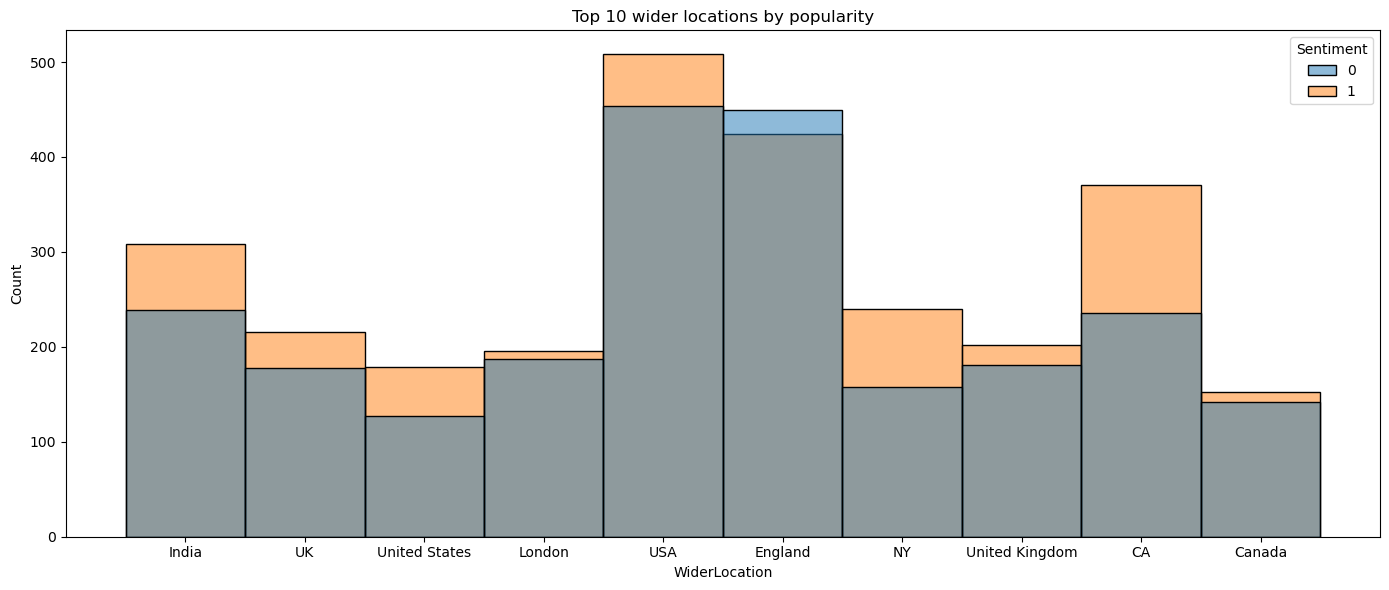

In [62]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.histplot(
    data=train[train.WiderLocation.isin(top_wider_locs)],
    x="WiderLocation",
    hue="Sentiment",
)

ax.set_title("Top 10 wider locations by popularity")
plt.tight_layout()

Закодируйте признак WiderLocation с помощью OHE таким образом, чтобы создались только столбцы для местоположений, которые встречаются более одного раза. Сколько таких значений?


In [63]:
test["WiderLocation"] = test.Location.str.split(",").str[-1].str.strip()

In [64]:
frequent_locations = train.WiderLocation.value_counts()
frequent_locations = frequent_locations[frequent_locations > 1].index

wl_ohe = OneHotEncoder(
    categories=[frequent_locations],
    handle_unknown="ignore",
).fit(train[["WiderLocation"]])

In [65]:
(train.WiderLocation.value_counts() > 1).sum()

np.int64(988)

Всего 988 уникальных значений WiderLocation, для которых есть более одного твита

Добавьте этот признак к матрице отскалированных текстовых признаков, обучите логистическую регрессию, замерьте качество. Как оно изменилось? Оказался ли признак полезным?


*Подсказка:* используйте параметр `categories` в энкодере.

In [66]:
train_wl = wl_ohe.transform(train[["WiderLocation"]])
test_wl = wl_ohe.transform(test[["WiderLocation"]])

X_train = hstack([scaled_X_train, train_wl])
X_test = hstack([scaled_X_test, test_wl])

In [67]:
model = LogisticRegression().fit(X_train, y_train)

print("LogisticRegression with CountVectorizer, min_df, StandardScaler and WiderLocation")
print(f"\tTrain accuracy: {accuracy_score(y_train, model.predict(X_train))}")
print(f"\tTest accuracy: {accuracy_score(y_test, model.predict(X_test))}")

LogisticRegression with CountVectorizer, min_df, StandardScaler and WiderLocation
	Train accuracy: 0.9449807774455361
	Test accuracy: 0.8444289415985649


**Ответ:** accuracy на train выросла на тысячные доли, а test упала на десятитысячные. Можно сказать, что признак ни на что не повлиял и смысла от него нет.